In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
df = pd.read_csv('dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB


In [3]:
df.sample(10)

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
238443,80,'C1579865062','1','F','28007','M1823072687','28007','es_transportation',14.17,0
465504,145,'C691839786','3','M','28007','M1823072687','28007','es_transportation',28.52,0
370591,118,'C1689772812','2','M','28007','M1823072687','28007','es_transportation',39.12,0
364366,117,'C1987985724','2','M','28007','M1823072687','28007','es_transportation',33.04,0
460193,143,'C586830923','4','M','28007','M1823072687','28007','es_transportation',12.15,0
228861,77,'C1483007108','1','F','28007','M1823072687','28007','es_transportation',30.63,0
576734,175,'C1127983201','6','F','28007','M1823072687','28007','es_transportation',62.90,0
485587,150,'C954150626','6','F','28007','M348934600','28007','es_transportation',58.07,0
97899,35,'C862633345','4','F','28007','M1823072687','28007','es_transportation',0.79,0
262551,87,'C1629152705','6','M','28007','M348934600','28007','es_transportation',8.40,0


In [4]:
# Check for missing values
print(df.isnull().sum())

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64


In [5]:
df.drop(['zipcodeOri', 'zipMerchant'], axis=1, inplace=True)
df.sample(10)

,step,customer,age,gender,merchant,category,amount,fraud
542583,166,'C1023694383','6','F','M1823072687','es_transportation',57.90,0
29821,11,'C2079453894','3','F','M1823072687','es_transportation',74.95,0
505321,155,'C206074131','5','F','M85975013','es_food',28.03,0
16601,6,'C980876590','2','F','M348934600','es_transportation',22.88,0
329033,106,'C1436301390','2','F','M1823072687','es_transportation',2.19,0
92285,34,'C1047374909','6','F','M348934600','es_transportation',11.25,0
527330,161,'C1082608644','4','F','M1823072687','es_transportation',30.49,0
370277,118,'C1776310825','4','M','M348934600','es_transportation',6.23,0
566210,172,'C900337975','2','M','M1823072687','es_transportation',11.84,0
311909,102,'C1171394321','4','M','M348934600','es_transportation',26.29,0


In [ ]:
df.drop(['amount'], axis=1, inplace=True)
df.sample(10)

,step,customer,age,gender,merchant,category,fraud
43208,16,'C1344489848','4','F','M151143676','es_barsandrestaurants',0
472245,146,'C489185823','4','F','M348934600','es_transportation',0
136264,48,'C709211172','4','F','M85975013','es_food',0
353756,114,'C1082608644','4','F','M1823072687','es_transportation',0
2989,1,'C1076053396','4','M','M348934600','es_transportation',0
54097,20,'C980876590','2','F','M348934600','es_transportation',0
404719,128,'C1621267054','2','F','M1823072687','es_transportation',0
339650,110,'C371517012','2','M','M2122776122','es_home',1
481373,149,'C1264224372','4','M','M1913465890','es_health',0
423102,133,'C1741401017','4','M','M1823072687','es_transportation',0


In [ ]:
df.sample(10)

,step,customer,age,gender,merchant,category,fraud
382783,122,'C350348759','2','F','M1946091778','es_wellnessandbeauty',0
275164,91,'C1853381059','4','M','M348934600','es_transportation',0
457688,142,'C267284908','4','F','M1823072687','es_transportation',0
456246,142,'C1149179033','5','M','M1823072687','es_transportation',0
481597,149,'C99215049','4','M','M1823072687','es_transportation',0
482669,149,'C17059521','2','M','M1823072687','es_transportation',0
252948,84,'C722887134','2','M','M1053599405','es_health',0
593421,179,'C1425719203','1','F','M1823072687','es_transportation',0
198205,68,'C1471216995','3','F','M348934600','es_transportation',0
151530,53,'C2068249421','5','M','M348934600','es_transportation',0


In [ ]:
df[df['fraud'] == 1].sum()

step                                                   644400
customer    'C583110837''C1332295774''C1160421902''C966214...
age         '3''3''3''3''4''2''2''5''4''3''3''1''2''2''5''...
gender      'M''M''M''M''F''F''F''F''F''F''M''F''F''F''F''...
merchant    'M480139044''M480139044''M857378720''M85737872...
category    'es_health''es_health''es_hotelservices''es_ho...
fraud                                                    7200
dtype: object

In [ ]:
# adding an attribute count of past transactions
df['txn_count_customer'] = df.groupby('customer').cumcount()

In [ ]:
df.head(20)

,step,customer,age,gender,merchant,category,fraud,txn_count_customer
0,0,'C1093826151','4','M','M348934600','es_transportation',0,0
1,0,'C352968107','2','M','M348934600','es_transportation',0,0
2,0,'C2054744914','4','F','M1823072687','es_transportation',0,0
3,0,'C1760612790','3','M','M348934600','es_transportation',0,0
4,0,'C757503768','5','M','M348934600','es_transportation',0,0
5,0,'C1315400589','3','F','M348934600','es_transportation',0,0
6,0,'C765155274','1','F','M348934600','es_transportation',0,0
7,0,'C202531238','4','F','M348934600','es_transportation',0,0
8,0,'C105845174','3','M','M348934600','es_transportation',0,0
9,0,'C39858251','5','F','M348934600','es_transportation',0,0


In [ ]:
# Display transactions for a single customer, for example the first customer in the dataframe
single_customer_id = df['customer'].iloc[0]
df[df['customer'] == single_customer_id]

,step,customer,age,gender,merchant,category,fraud,txn_count_customer
0,0,'C1093826151','4','M','M348934600','es_transportation',0,0
2497,1,'C1093826151','4','M','M855959430','es_hyper',0,1
5076,2,'C1093826151','4','M','M348934600','es_transportation',0,2
8664,3,'C1093826151','4','M','M348934600','es_transportation',0,3
9936,4,'C1093826151','4','M','M348934600','es_transportation',0,4
...,...,...,...,...,...,...,...,...
577785,175,'C1093826151','4','M','M348934600','es_transportation',0,162
579805,176,'C1093826151','4','M','M348934600','es_transportation',0,163
584013,177,'C1093826151','4','M','M348934600','es_transportation',0,164
590115,178,'C1093826151','4','M','M348934600','es_transportation',0,165


In [ ]:
amount_threshold_nearest = df['inr_amount'].quantile(0.95, interpolation='nearest')
amount_threshold_highest = df['inr_amount'].quantile(0.95, interpolation='higher')
amount_threshold_linear = df['inr_amount'].quantile(0.95, interpolation='linear')
print(f"Nearest 95th percentile: {amount_threshold_nearest}")
print(f"Higher 95th percentile: {amount_threshold_highest}")
print(f"Linear 95th percentile: {amount_threshold_linear}")

KeyError: 'inr_amount'

In [ ]:
df['is_high_amount'] = (df['inr_amount'] > amount_threshold_nearest).astype(int)

In [ ]:
fraud_rate_per_category = df.groupby('category')['fraud'].mean().reset_index()

df['category_fraud_rate'] = df['category'].map(fraud_rate_per_category.set_index('category')['fraud'])

In [ ]:
df.sample(10)

,step,customer,age,gender,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate
570724,173,'C1999090638','2','F','M1823072687','es_transportation',0,1058.54,152,0,0.0000
175781,61,'C1629765833','2','F','M85975013','es_food',0,6423.72,58,0,0.0000
216569,73,'C187965576','1','M','M3697346','es_leisure',0,4608.51,57,0,0.9499
43704,16,'C757950779','6','M','M348934600','es_transportation',0,75.47,13,0,0.0000
593619,179,'C458379262','5','F','M1823072687','es_transportation',0,3187.53,168,0,0.0000
512098,157,'C664109131','2','F','M1823072687','es_transportation',0,4718.74,54,0,0.0000
435325,136,'C1984083185','3','F','M1823072687','es_transportation',0,1124.08,104,0,0.0000
358226,115,'C805483863','4','F','M348934600','es_transportation',0,747.73,106,0,0.0000
413964,130,'C1474149613','2','M','M1823072687','es_transportation',0,4737.60,108,0,0.0000
325743,106,'C1087227796','2','M','M348934600','es_transportation',0,918.52,70,0,0.0000


In [ ]:
top_5_categories = df.groupby('category')['category_fraud_rate'].mean().sort_values(ascending=False)
print(top_5_categories)

category
'es_leisure'               0.949900
'es_travel'                0.793956
'es_sportsandtoys'         0.495252
'es_hotelservices'         0.314220
'es_otherservices'         0.250000
'es_home'                  0.152064
'es_health'                0.105126
'es_tech'                  0.066667
'es_wellnessandbeauty'     0.047594
'es_hyper'                 0.045917
'es_barsandrestaurants'    0.018829
'es_fashion'               0.017973
'es_contents'              0.000000
'es_food'                  0.000000
'es_transportation'        0.000000
Name: category_fraud_rate, dtype: float64


In [ ]:
txn_count_per_category = df['category'].value_counts().to_dict()

df['txn_count_category'] = df['category'].map(txn_count_per_category)

In [ ]:
df.sample(10)

,step,customer,age,gender,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category
270073,89,'C1158029630','4','M','M348934600','es_transportation',0,2243.19,12,0,0.0,505119
186407,64,'C455036670','2','M','M1823072687','es_transportation',0,6146.67,57,0,0.0,505119
357584,115,'C1283534588','3','M','M1823072687','es_transportation',0,4216.28,113,0,0.0,505119
508625,156,'C920335350','2','F','M348934600','es_transportation',0,1080.38,92,0,0.0,505119
4835,1,'C188991095','4','F','M348934600','es_transportation',0,6188.38,1,0,0.0,505119
14022,5,'C403631555','4','M','M348934600','es_transportation',0,2073.38,4,0,0.0,505119
161893,56,'C1028143403','3','M','M1823072687','es_transportation',0,432.95,55,0,0.0,505119
86486,32,'C1734948367','3','M','M348934600','es_transportation',0,5673.01,16,0,0.0,505119
219411,74,'C1308910127','5','M','M348934600','es_transportation',0,4188.47,24,0,0.0,505119
252606,84,'C1040272582','2','M','M1823072687','es_transportation',0,2123.03,78,0,0.0,505119


In [ ]:
fraud_count_per_gender = df[df['fraud'] == 1]['gender'].value_counts()
print(fraud_count_per_gender)

gender
'F'    4758
'M'    2435
'E'       7
Name: count, dtype: int64


In [ ]:
df[df['gender'] == "'E'"].sample(10)

,step,customer,age,gender,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category
6926,2,'C1374607221','U','E','M1823072687','es_transportation',0,1953.23,2,0,0.000000,505119
13863,5,'C2075935351','U','E','M1053599405','es_health',0,6812.97,4,0,0.105126,16133
491188,152,'C808326652','U','E','M1913465890','es_health',0,20308.84,149,1,0.105126,16133
127633,45,'C914000857','U','E','M1823072687','es_transportation',0,1004.92,43,0,0.000000,505119
523938,160,'C1374607221','U','E','M677738360','es_contents',0,3073.34,148,0,0.000000,885
175958,61,'C1374607221','U','E','M348934600','es_transportation',0,744.75,62,0,0.000000,505119
277813,92,'C914000857','U','E','M1823072687','es_transportation',0,4983.87,95,0,0.000000,505119
560372,170,'C808326652','U','E','M1823072687','es_transportation',0,110.22,165,0,0.000000,505119
587005,177,'C1374607221','U','E','M1823072687','es_transportation',0,4616.46,164,0,0.000000,505119
259460,86,'C1152835627','U','E','M1823072687','es_transportation',0,72.49,56,0,0.000000,505119


In [ ]:
df.drop(['gender'], axis=1, inplace=True)

In [ ]:
df.head(10)

,step,customer,age,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category
0,0,'C1093826151','4','M348934600','es_transportation',0,451.81,0,0,0.0,505119
1,0,'C352968107','2','M348934600','es_transportation',0,3940.22,0,0,0.0,505119
2,0,'C2054744914','4','M1823072687','es_transportation',0,2670.18,0,0,0.0,505119
3,0,'C1760612790','3','M348934600','es_transportation',0,1712.92,0,0,0.0,505119
4,0,'C757503768','5','M348934600','es_transportation',0,3547.00,0,0,0.0,505119
5,0,'C1315400589','3','M348934600','es_transportation',0,2562.93,0,0,0.0,505119
6,0,'C765155274','1','M348934600','es_transportation',0,903.63,0,0,0.0,505119
7,0,'C202531238','4','M348934600','es_transportation',0,2102.18,0,0,0.0,505119
8,0,'C105845174','3','M348934600','es_transportation',0,3217.32,0,0,0.0,505119
9,0,'C39858251','5','M348934600','es_transportation',0,3515.22,0,0,0.0,505119


In [ ]:
df_sorted = df.sort_values(by=['customer', 'step'])

df_sorted['cumulative_fraud'] = df_sorted.groupby('customer')['fraud'].cumsum().shift(1).fillna(0)
df_sorted['cumulative_transactions'] = df_sorted.groupby('customer').cumcount()

# Calculate fraud rate, handle division by zero, and align with original df index
customer_fraud_rate = (df_sorted['cumulative_fraud'] / df_sorted['cumulative_transactions']).replace([np.inf, -np.inf], 0).fillna(0)
df['customer_fraud_rate'] = customer_fraud_rate.sort_index()

In [ ]:
df.sample(10)

,step,customer,age,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category,customer_fraud_rate
524248,161,'C1272326382','1','M85975013','es_food',0,1097.27,150,0,0.0,26254,0.013333
316850,103,'C521129957','5','M1823072687','es_transportation',0,64.55,21,0,0.0,505119,0.000000
417051,131,'C483009385','3','M348934600','es_transportation',0,149.94,131,0,0.0,505119,0.000000
98349,36,'C152830802','2','M348934600','es_transportation',0,1587.81,34,0,0.0,505119,0.000000
237466,80,'C1202775726','3','M1823072687','es_transportation',0,1805.27,53,0,0.0,505119,0.037736
550283,168,'C2100466386','2','M1823072687','es_transportation',0,1907.55,161,0,0.0,505119,0.018634
150313,53,'C2016890783','5','M348934600','es_transportation',0,5341.35,48,0,0.0,505119,0.000000
278931,92,'C851731350','4','M348934600','es_transportation',0,1100.24,88,0,0.0,505119,0.000000
309458,101,'C1100570635','4','M348934600','es_transportation',0,1794.35,85,0,0.0,505119,0.023529
330042,107,'C1452354279','3','M1823072687','es_transportation',0,7034.41,104,0,0.0,505119,0.000000


In [ ]:
top_fraudsters = df.groupby('customer')['customer_fraud_rate'].mean().sort_values(ascending=False).head(10)
print(top_fraudsters)

customer
'C2004941826'    0.960703
'C2113737065'    0.948078
'C910454738'     0.945105
'C1572610482'    0.934272
'C1849046345'    0.921552
'C1350963410'    0.914309
'C1175850429'    0.883581
'C1464489812'    0.874698
'C1685492470'    0.850126
'C126638730'     0.821230
Name: customer_fraud_rate, dtype: float64


In [ ]:
df[df['customer'] == "'C2004941826'"].count()

step                   126
customer               126
age                    126
merchant               126
category               126
fraud                  126
inr_amount             126
txn_count_customer     126
is_high_amount         126
category_fraud_rate    126
txn_count_category     126
customer_fraud_rate    126
dtype: int64

In [ ]:
df[(df['customer'] == "'C2004941826'") & (df['fraud'] == 0)]

,step,customer,age,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category,customer_fraud_rate
234014,79,'C2004941826','2','M692898500','es_health',0,18220.56,47,1,0.105126,16133,1.000000
272158,90,'C2004941826','2','M1198415165','es_wellnessandbeauty',0,1394.17,59,0,0.047594,15086,0.983051
309794,101,'C2004941826','2','M480139044','es_health',0,4019.66,66,0,0.105126,16133,0.969697
332445,107,'C2004941826','2','M480139044','es_health',0,2711.88,72,0,0.105126,16133,0.958333
332446,107,'C2004941826','2','M50039827','es_health',0,5885.51,73,0,0.105126,16133,0.945205
363904,116,'C2004941826','2','M980657600','es_sportsandtoys',0,10034.26,81,1,0.495252,4002,0.938272
525822,161,'C2004941826','2','M348875670','es_hotelservices',0,15878.07,115,1,0.314220,1744,0.947826


In [ ]:
df_merchant_sort = df.sort_values(by=['merchant', 'step'])
df_merchant_sort['cumulative_fraud'] = df_merchant_sort.groupby('merchant')['fraud'].cumsum().shift(1).fillna(0)
df_merchant_sort['cumulative_transactions'] = df_merchant_sort.groupby('merchant').cumcount()
# Calculate fraud rate for merchants, handle division by zero, and align with original df index
merchant_fraud_rate = (df_merchant_sort['cumulative_fraud'] / df_merchant_sort['cumulative_transactions']).replace([np.inf, -np.inf], 0).fillna(0)
df['merchant_fraud_rate'] = merchant_fraud_rate.sort_index()

In [ ]:
top_merch_fraudsters = df.groupby('merchant')['merchant_fraud_rate'].mean().sort_values(ascending=False).head(10)
print(top_merch_fraudsters)

merchant
'M1294758098'    0.949741
'M3697346'       0.926821
'M732195782'     0.794567
'M980657600'     0.792851
'M1353266412'    0.752955
'M2080407379'    0.739167
'M1873032707'    0.715476
'M17379832'      0.696598
'M857378720'     0.629141
'M2011752106'    0.531729
Name: merchant_fraud_rate, dtype: float64


In [ ]:
df[df['merchant'] == "'M1294758098'"].count()

step                   191
customer               191
age                    191
merchant               191
category               191
fraud                  191
inr_amount             191
txn_count_customer     191
is_high_amount         191
category_fraud_rate    191
txn_count_category     191
customer_fraud_rate    191
merchant_fraud_rate    191
dtype: int64

In [ ]:
df[(df['merchant'] == "'M1294758098'") & (df['fraud'] == 0)]

,step,customer,age,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category,customer_fraud_rate,merchant_fraud_rate
10245,4,'C1480367576','3','M1294758098','es_leisure',0,9984.61,1,1,0.9499,499,0.000000,1.000000
33059,12,'C440694138','2','M1294758098','es_leisure',0,6500.18,1,0,0.9499,499,0.000000,0.941176
141989,50,'C1204780618','4','M1294758098','es_leisure',0,9647.99,6,1,0.9499,499,0.000000,0.965517
278243,92,'C350034124','1','M1294758098','es_leisure',0,6060.28,8,0,0.9499,499,0.000000,0.972477
292512,96,'C1685492470','2','M1294758098','es_leisure',0,7068.17,44,0,0.9499,499,0.886364,0.964286
372060,119,'C103995111','3','M1294758098','es_leisure',0,7631.20,7,0,0.9499,499,0.142857,0.964029
397585,126,'C651594350','3','M1294758098','es_leisure',0,4552.90,95,0,0.9499,499,0.000000,0.958904


In [ ]:
fraud_count_per_age = df[df['fraud'] == 1]['age'].value_counts()
print(fraud_count_per_age)

age
'2'    2344
'3'    1755
'4'    1410
'1'     689
'5'     686
'6'     261
'0'      48
'U'       7
Name: count, dtype: int64


In [ ]:
df['txn_count_merch'] = df.groupby('merchant').cumcount()
df.head(10)

,step,customer,age,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category,customer_fraud_rate,merchant_fraud_rate,txn_count_merch
0,0,'C1093826151','4','M348934600','es_transportation',0,451.81,0,0,0.0,505119,0.0,0.0,0
1,0,'C352968107','2','M348934600','es_transportation',0,3940.22,0,0,0.0,505119,0.0,0.0,1
2,0,'C2054744914','4','M1823072687','es_transportation',0,2670.18,0,0,0.0,505119,0.0,0.0,0
3,0,'C1760612790','3','M348934600','es_transportation',0,1712.92,0,0,0.0,505119,0.0,0.0,2
4,0,'C757503768','5','M348934600','es_transportation',0,3547.00,0,0,0.0,505119,0.0,0.0,3
5,0,'C1315400589','3','M348934600','es_transportation',0,2562.93,0,0,0.0,505119,0.0,0.0,4
6,0,'C765155274','1','M348934600','es_transportation',0,903.63,0,0,0.0,505119,0.0,0.0,5
7,0,'C202531238','4','M348934600','es_transportation',0,2102.18,0,0,0.0,505119,0.0,0.0,6
8,0,'C105845174','3','M348934600','es_transportation',0,3217.32,0,0,0.0,505119,0.0,0.0,7
9,0,'C39858251','5','M348934600','es_transportation',0,3515.22,0,0,0.0,505119,0.0,0.0,8


In [ ]:
df['inr_amount'].max(), df['inr_amount'].min()

(827165.03, 0.0)

In [ ]:
df[df['inr_amount'] == 0.0]

,step,customer,age,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category,customer_fraud_rate,merchant_fraud_rate,txn_count_merch
40502,15,'C1918953803','2','M348934600','es_transportation',0,0.0,15,0,0.0,505119,0.000000,0.0,25451
46361,17,'C782199851','2','M348934600','es_transportation',0,0.0,17,0,0.0,505119,0.000000,0.0,28840
48560,18,'C92282564','3','M348934600','es_transportation',0,0.0,17,0,0.0,505119,0.000000,0.0,30082
64613,24,'C612357573','6','M348934600','es_transportation',0,0.0,22,0,0.0,505119,0.000000,0.0,38939
84320,31,'C1299474405','4','M348934600','es_transportation',0,0.0,29,0,0.0,505119,0.000000,0.0,49027
87713,32,'C1814870538','3','M1823072687','es_transportation',0,0.0,33,0,0.0,505119,0.000000,0.0,23626
88889,32,'C1189224644','2','M1823072687','es_transportation',0,0.0,32,0,0.0,505119,0.000000,0.0,24048
89155,32,'C1598762673','3','M1823072687','es_transportation',0,0.0,32,0,0.0,505119,0.000000,0.0,24157
127028,45,'C876944738','2','M1823072687','es_transportation',0,0.0,44,0,0.0,505119,0.000000,0.0,38376
133555,47,'C73919470','3','M348934600','es_transportation',0,0.0,43,0,0.0,505119,0.000000,0.0,72377


In [ ]:
## Remove rows with zero amount
df = df[df['inr_amount'] != 0.0]
df['inr_amount'].max(), df['inr_amount'].min()

(827165.03, 0.99)

In [ ]:
df.drop('age', axis=1, inplace=True)

In [ ]:
df.sample(10)

,step,customer,merchant,category,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category,customer_fraud_rate,merchant_fraud_rate,txn_count_merch
26117,10,'C378899672','M1823072687','es_transportation',0,4880.59,9,0,0.0,505119,0.000000,0.0,5259
121804,43,'C599293124','M348934600','es_transportation',0,3896.53,38,0,0.0,505119,0.000000,0.0,67088
37308,14,'C285545076','M348934600','es_transportation',0,2967.08,12,0,0.0,505119,0.000000,0.0,23605
553393,168,'C1778762788','M1823072687','es_transportation',0,5460.51,161,0,0.0,505119,0.000000,0.0,272750
176809,61,'C339931011','M1823072687','es_transportation',0,1415.02,59,0,0.0,505119,0.000000,0.0,59869
242489,81,'C748216113','M1823072687','es_transportation',0,2259.07,70,0,0.0,505119,0.000000,0.0,90977
463474,144,'C2136232396','M1823072687','es_transportation',0,608.71,129,0,0.0,505119,0.000000,0.0,215636
173398,60,'C1264836741','M348934600','es_transportation',0,6721.62,57,0,0.0,505119,0.000000,0.0,89096
454572,142,'C245908628','M1823072687','es_transportation',0,5869.62,133,0,0.0,505119,0.000000,0.0,210169
441472,138,'C1179217322','M348934600','es_transportation',0,1385.23,110,0,0.0,505119,0.009091,0.0,172971


In [ ]:
df.to_csv('C:/UCO-Hackathon/AIML part/Dataset/BankSim-Updated-Processed.csv', index=False)

Post feature engineering work

In [ ]:
df = pd.read_csv('C:/UCO-Hackathon/AIML part/Dataset/BankSim-Updated-Processed.csv')

In [ ]:
## check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")
else:
    print("No duplicates found.")


Number of duplicate rows: 0
No duplicates found.


In [ ]:
## One hot encoding for category
df = pd.get_dummies(df, columns=['category'], prefix='categoy_')

In [ ]:
df.sample(10)

,step,customer,merchant,fraud,inr_amount,txn_count_customer,is_high_amount,category_fraud_rate,txn_count_category,customer_fraud_rate,...,categoy__'es_home',categoy__'es_hotelservices',categoy__'es_hyper',categoy__'es_leisure',categoy__'es_otherservices',categoy__'es_sportsandtoys',categoy__'es_tech',categoy__'es_transportation',categoy__'es_travel',categoy__'es_wellnessandbeauty'
18716,7,'C98687952','M348934600',0,697.09,1,0,0.000000,505119,0.000000,...,False,False,False,False,False,False,False,True,False,False
550362,168,'C1374607221','M1823072687',0,3134.90,156,0,0.000000,505119,0.000000,...,False,False,False,False,False,False,False,True,False,False
139534,49,'C1187730955','M348934600',0,3762.48,45,0,0.000000,505119,0.000000,...,False,False,False,False,False,False,False,True,False,False
421818,133,'C1758950662','M151143676',0,5368.16,6,0,0.018829,6373,0.000000,...,False,False,False,False,False,False,False,False,False,False
183108,63,'C2035771335','M1823072687',0,1181.67,63,0,0.000000,505119,0.000000,...,False,False,False,False,False,False,False,True,False,False
233827,79,'C2084449024','M1823072687',0,1383.25,78,0,0.000000,505119,0.000000,...,False,False,False,False,False,False,False,True,False,False
295334,97,'C1890191192','M348934600',0,1829.11,63,0,0.000000,505119,0.000000,...,False,False,False,False,False,False,False,True,False,False
500900,154,'C1110919755','M348934600',0,3968.03,128,0,0.000000,505119,0.007812,...,False,False,False,False,False,False,False,True,False,False
27956,11,'C1943207086','M348934600',0,2753.59,11,0,0.000000,505119,0.000000,...,False,False,False,False,False,False,False,True,False,False
288363,95,'C605522883','M151143676',0,1472.62,85,0,0.018829,6373,0.011765,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594591 entries, 0 to 594590
Data columns (total 27 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   step                              594591 non-null  int64  
 1   customer                          594591 non-null  object 
 2   merchant                          594591 non-null  object 
 3   fraud                             594591 non-null  int64  
 4   inr_amount                        594591 non-null  float64
 5   txn_count_customer                594591 non-null  int64  
 6   is_high_amount                    594591 non-null  int64  
 7   category_fraud_rate               594591 non-null  float64
 8   txn_count_category                594591 non-null  int64  
 9   customer_fraud_rate               594591 non-null  float64
 10  merchant_fraud_rate               594591 non-null  float64
 11  txn_count_merch                   594591 non-null  i

In [ ]:
df.drop(['step'], axis=1, inplace=True)

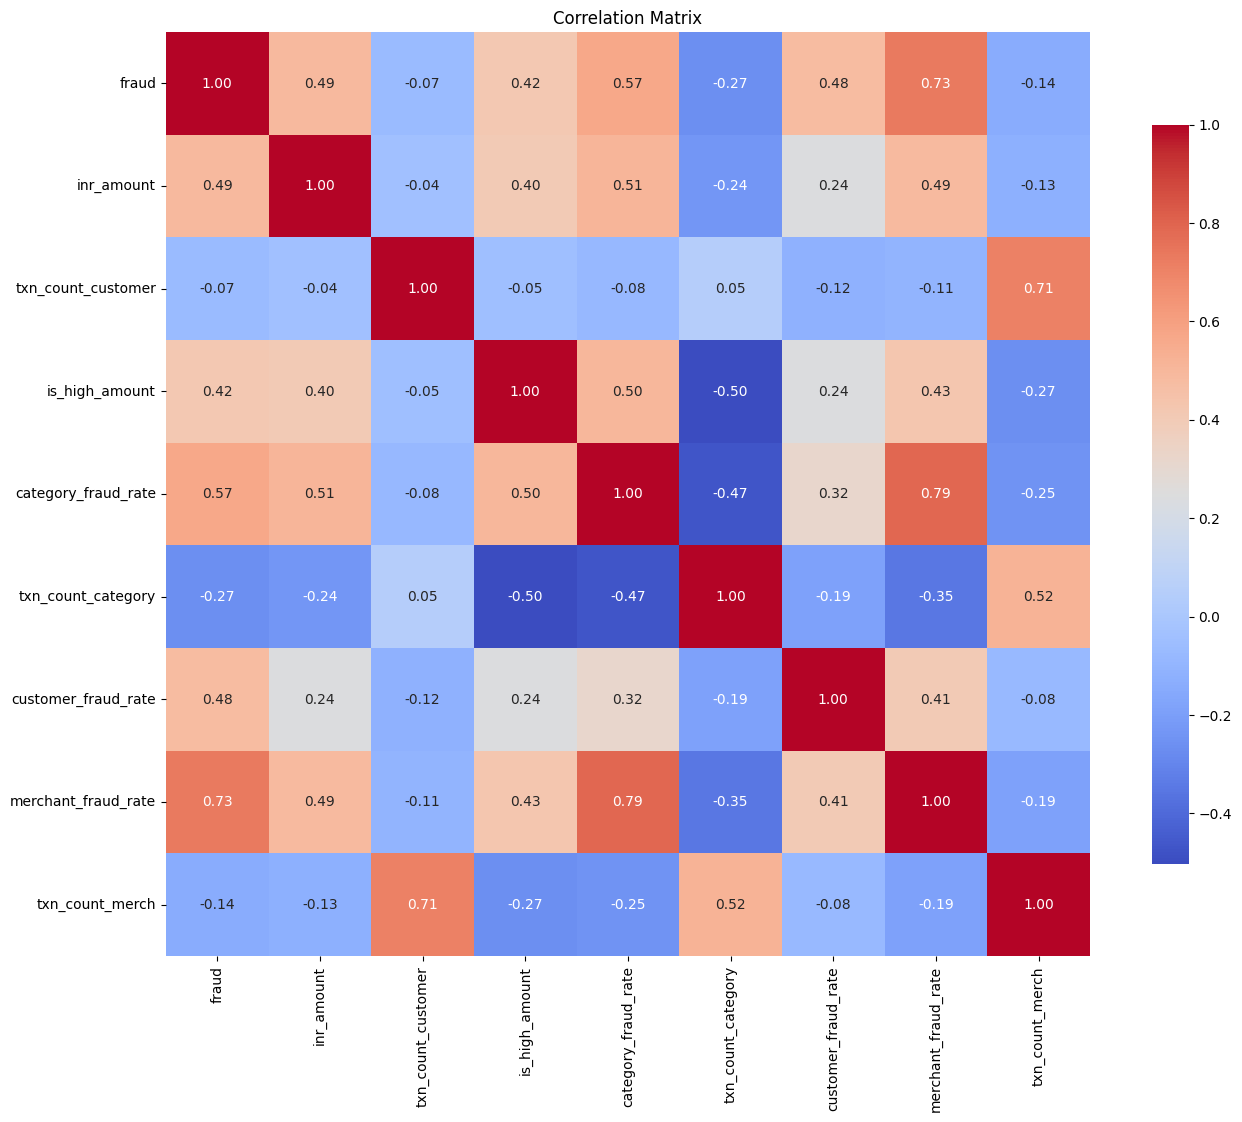

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")
plt.show()

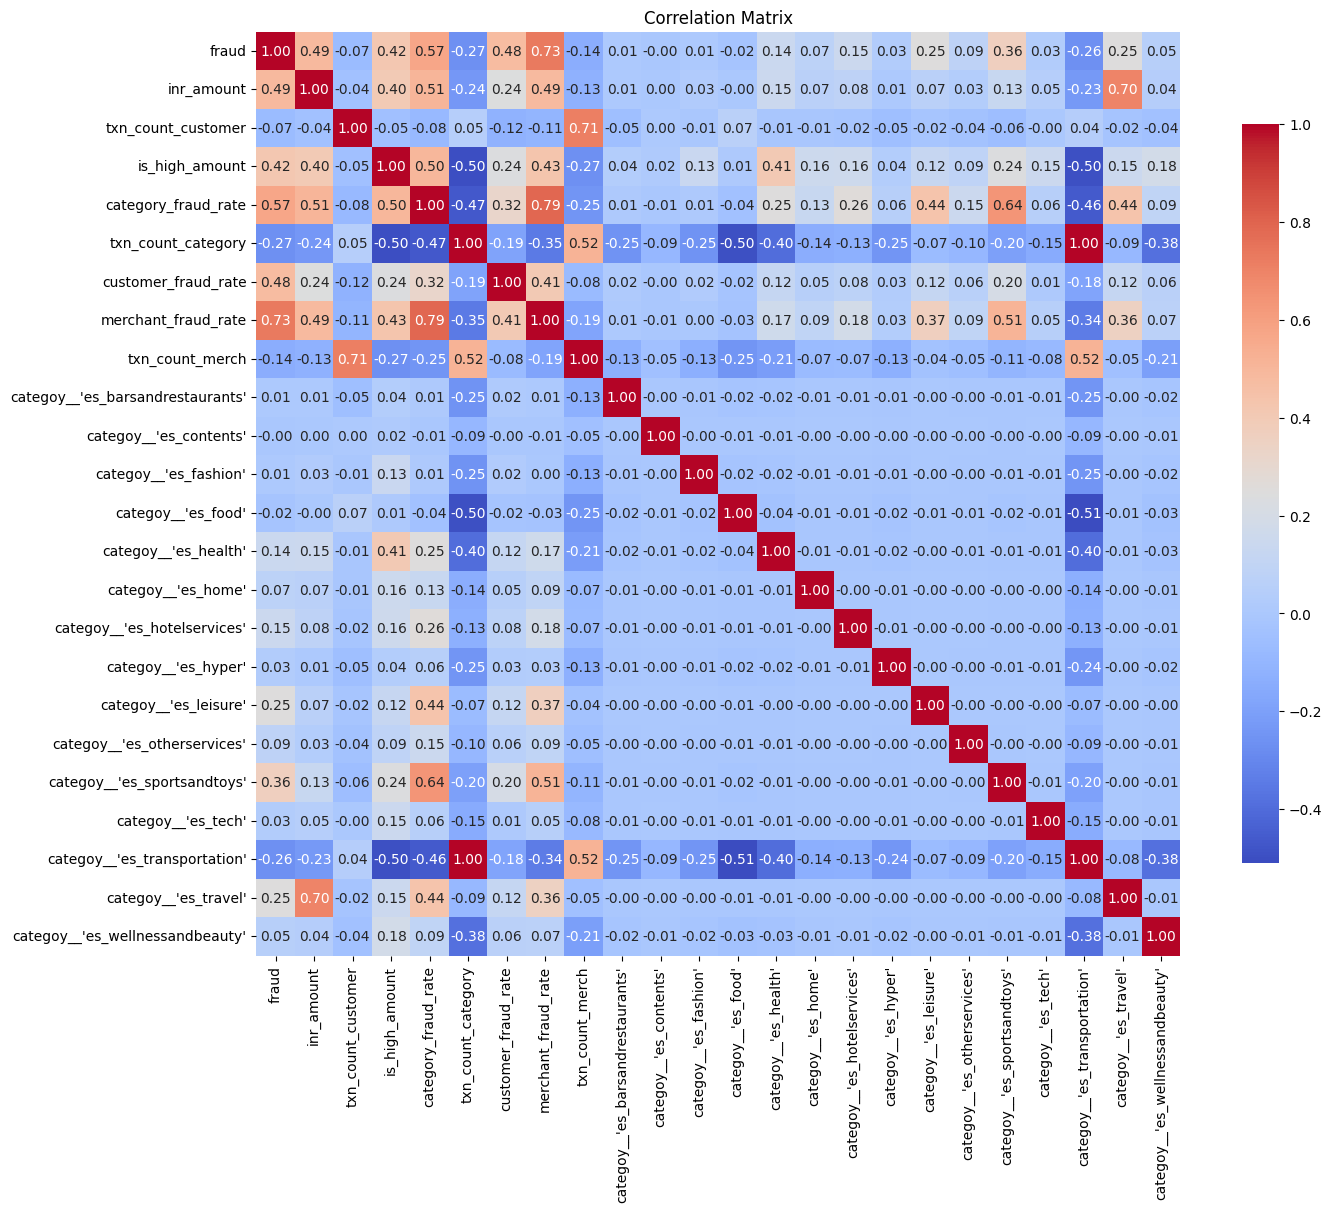

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")
plt.show()

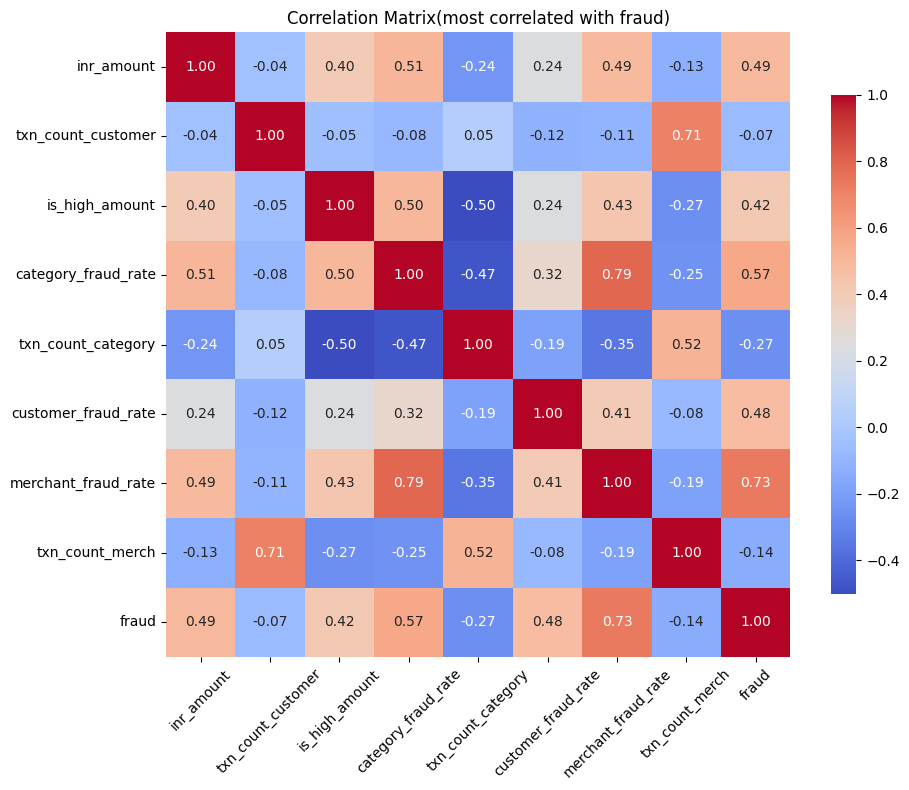

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
fraud_corr = corr_matrix['fraud'].drop('fraud')

threshold = 0.05

strong_corr_features = fraud_corr[abs(fraud_corr) > threshold].index.tolist()

selected_features = strong_corr_features + ['fraud']
plt.figure(figsize=(10, 8))
sns.heatmap(df[selected_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix(most correlated with fraud)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.columns.to_list()

['customer',
 'merchant',
 'fraud',
 'inr_amount',
 'txn_count_customer',
 'is_high_amount',
 'category_fraud_rate',
 'txn_count_category',
 'customer_fraud_rate',
 'merchant_fraud_rate',
 'txn_count_merch',
 "categoy__'es_barsandrestaurants'",
 "categoy__'es_contents'",
 "categoy__'es_fashion'",
 "categoy__'es_food'",
 "categoy__'es_health'",
 "categoy__'es_home'",
 "categoy__'es_hotelservices'",
 "categoy__'es_hyper'",
 "categoy__'es_leisure'",
 "categoy__'es_otherservices'",
 "categoy__'es_sportsandtoys'",
 "categoy__'es_tech'",
 "categoy__'es_transportation'",
 "categoy__'es_travel'",
 "categoy__'es_wellnessandbeauty'"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['customer', 'merchant', 'fraud'])
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
model = XGBClassifier(n_estimators=500, use_label_encoder=False, eval_metric='logloss')

model.fit(X_train, y_train)

c:\Program Files\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:19:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC AUC Score:")
print(roc_auc_score(y_test, y_pred_proba))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    117479
           1       0.87      0.82      0.85      1440

    accuracy                           1.00    118919
   macro avg       0.94      0.91      0.92    118919
weighted avg       1.00      1.00      1.00    118919

Confusion Matrix:
[[117308    171]
 [   258   1182]]
ROC AUC Score:
0.9976866610202675


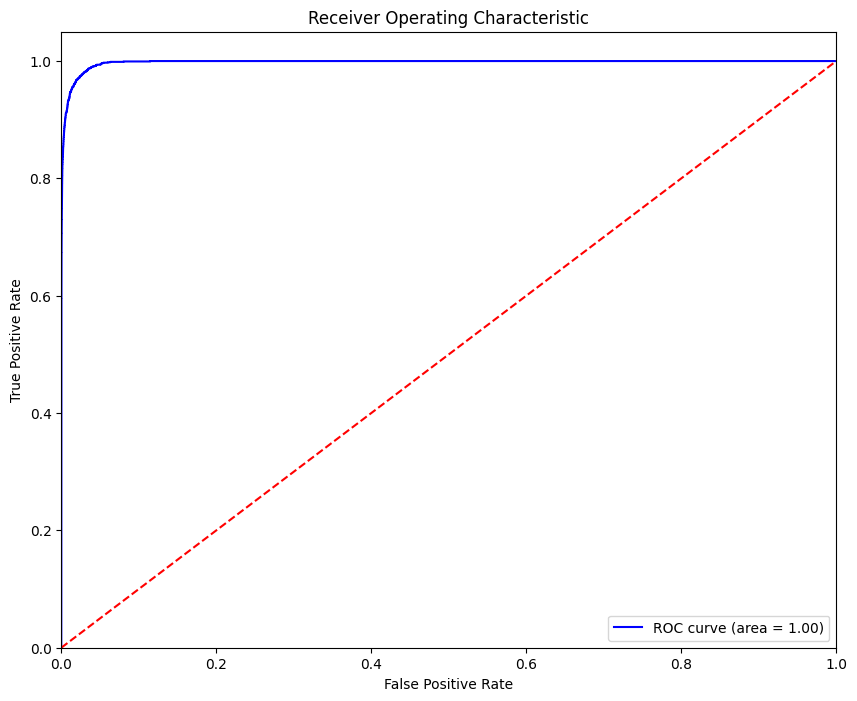

In [ ]:
## Plot ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()